<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# Smart-Turn — load exported dataset

Entry-point notebook for the smart-turn workflow. It picks up where
[`wk exports adapt smart-turn`](https://github.com/wavekat/wavekat-cli) leaves
off: a directory of Parquet shards plus a `wavekat_export_meta.json`
provenance file.

What this notebook does:

1. Load `train` / `validation` / `test` Parquet shards into a
   `DatasetDict` with the HuggingFace `Audio` feature attached.
2. Sanity-check the splits — counts, label balance, clip-duration
   distribution.
3. Audition a few clips from each class so you know the audio is
   actually decoding.
4. Show the export provenance so a future reader can trace this
   notebook back to the snapshot that produced it.

Downstream notebooks (training, eval) consume the same `ds` shape this
notebook produces — keep the loader cell stable.

## Configure

Point `EXPORT_DIR` at whatever directory you passed to `wk exports adapt
smart-turn --out`. The default below assumes the example layout from the
wavekat-cli README (`./datasets/smart-turn-zh`).

In [14]:
from pathlib import Path

EXPORT_DIR = Path("../../datasets/smart-turn-zh-0503").resolve()
TARGET_SR = 16_000  # smart-turn operates at 16 kHz; the adapter writes at 16 kHz too.

assert EXPORT_DIR.exists(), (
    f"{EXPORT_DIR} does not exist. Run `wk exports adapt smart-turn --out {EXPORT_DIR}` first, "
    f"or edit EXPORT_DIR above."
)
# Print the dir name + contents — full absolute path is omitted on purpose
# so committed outputs don't bake in `/Users/<whoever>/...`.
print("export dir:", EXPORT_DIR.name)
print("contents :", sorted(p.name for p in EXPORT_DIR.iterdir()))

export dir: smart-turn-zh-0503
contents : ['README.md', 'test.parquet', 'train.parquet', 'validation.parquet', 'wavekat_export_meta.json']


## Load

`validation.parquet` and `test.parquet` are optional — the adapter only
writes a shard for splits that actually contain rows. We pick up
whatever is on disk so the notebook works for both full and train-only
exports.

In [15]:
from datasets import load_dataset, Audio, disable_progress_bars

# Suppress per-split "Generating train split: …" progress lines —
# the dataset is small enough that the bars are pure noise.
disable_progress_bars()

data_files = {
    split: str(EXPORT_DIR / f"{split}.parquet")
    for split in ("train", "validation", "test")
    if (EXPORT_DIR / f"{split}.parquet").exists()
}
assert "train" in data_files, "train.parquet is missing — adapt step did not produce it."

ds = load_dataset("parquet", data_files=data_files)
ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
ds

Task was destroyed but it is pending!
task: <Task pending name='Task-299' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-300' coro=<Kernel.shell_main() running at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/dataclasses.py:1293: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return tuple(f for f in fields.values() if f._field_type is _FIELD)
Task was destroyed but it is pending!
task: <Task pending name='Task-300' coro=<Kernel.shell_main() running at /Users/eason/Develo

DatasetDict({
    train: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 1888
    })
    validation: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 210
    })
    test: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 254
    })
})

## Split sizes and label balance

`endpoint_bool` is the binary smart-turn target — 1 = `end_of_turn`,
0 = `continuation`. A wildly skewed balance here is your earliest
warning that the export filter pulled the wrong slice.

In [16]:
import pandas as pd

rows = []
for split, dset in ds.items():
    labels = dset["endpoint_bool"]
    pos = sum(labels)
    neg = len(labels) - pos
    rows.append(
        {
            "split": split,
            "n": len(labels),
            "end_of_turn": pos,
            "continuation": neg,
            "% end_of_turn": round(100 * pos / max(len(labels), 1), 1),
        }
    )
pd.DataFrame(rows).set_index("split")

,n,end_of_turn,continuation,% end_of_turn
split,,,,
train,1888,940,948,49.8
validation,210,123,87,58.6
test,254,124,130,48.8


## Clip duration distribution

Smart-turn cares about the tail — clips much shorter or longer than the
rest will train poorly. The adapter passes `clip_duration_sec` through
from the canonical snapshot, so this is the source of truth (no decode
needed).

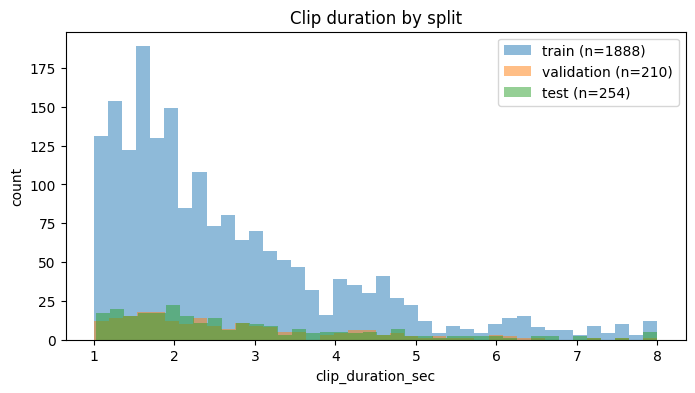

,train,validation,test
count,1888.000000,210.000000,254.000000
mean,2.648794,2.703626,2.823358
std,1.473531,1.407238,1.593317
min,1.000000,1.008000,1.023000
25%,1.576000,1.624000,1.637484
50%,2.172000,2.293938,2.306969
75%,3.289484,3.336234,3.539938
max,8.000000,8.000000,8.000000


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for split, dset in ds.items():
    durations = dset["clip_duration_sec"]
    ax.hist(durations, bins=40, alpha=0.5, label=f"{split} (n={len(durations)})")
ax.set_xlabel("clip_duration_sec")
ax.set_ylabel("count")
ax.set_title("Clip duration by split")
ax.legend()
plt.show()

pd.DataFrame(
    {split: pd.Series(dset["clip_duration_sec"]).describe() for split, dset in ds.items()}
)

## Audition

Listen to a sample of each class from `train`. If the playback widget
below is silent, the audio bytes round-tripped but didn't decode — most
likely a sample-rate mismatch between the export and `TARGET_SR`.

In [18]:
from IPython.display import Audio as AudioWidget, display
import random

random.seed(0)
train = ds["train"]
by_label = {0: [], 1: []}
for i, row in enumerate(train):
    by_label[row["endpoint_bool"]].append(i)
    if all(len(v) >= 8 for v in by_label.values()):
        break

for label, label_name in [(1, "end_of_turn"), (0, "continuation")]:
    sample_idx = random.sample(by_label[label], k=min(2, len(by_label[label])))
    for idx in sample_idx:
        row = train[idx]
        print(
            f"[{label_name}] {row['annotation_id']}  duration={row['clip_duration_sec']:.2f}s  "
            f"path={row['audio']['path']}"
        )
        display(AudioWidget(row["audio"]["array"], rate=row["audio"]["sampling_rate"]))

[end_of_turn] 0382e0b7-adad-4a62-8d73-cc24fd2825e2  duration=2.25s  path=clips/0382e0b7-adad-4a62-8d73-cc24fd2825e2.wav


[end_of_turn] 0393b5ea-b9b6-4caf-84a2-c71780a0394b  duration=1.02s  path=clips/0393b5ea-b9b6-4caf-84a2-c71780a0394b.wav


[continuation] 025062ed-3a04-4d70-9fbf-6f4783261c9c  duration=6.13s  path=clips/025062ed-3a04-4d70-9fbf-6f4783261c9c.wav


[continuation] 004cfad4-f603-467c-9a04-b61cf2b817e9  duration=1.56s  path=clips/004cfad4-f603-467c-9a04-b61cf2b817e9.wav


## Provenance

`wavekat_export_meta.json` is the breadcrumb that ties this notebook
back to the snapshot directory and `wk` invocation that produced it.
Save its contents into any downstream artifact (model card, eval
report) so the dataset is traceable.

In [19]:
import json

meta_path = EXPORT_DIR / "wavekat_export_meta.json"
meta = json.loads(meta_path.read_text()) if meta_path.exists() else None
meta

{'clips_dir': './snapshots/smart-turn-zh-0503/clips',
 'language': 'zh',
 'manifest': './snapshots/smart-turn-zh-0503/manifest.jsonl',
 'split_counts': {'test': 254, 'train': 1888, 'validation': 210},
 'tool': 'wk exports adapt smart-turn'}

## Next

`ds` is ready for training. Downstream notebooks:

- `02_<letter>_*.ipynb` — train one variant per file (e.g.
  `02_a_train_baseline.ipynb`, `02_b_train_specaugment.ipynb`).
- `03_compare.ipynb` — score every trained variant on `ds["test"]`,
  pick a winner.
- `04_export.ipynb` — ONNX FP32 + INT8 export and latency benchmark
  for the chosen winner.

All downstream notebooks reload the dataset using the same
`EXPORT_DIR` / `load_dataset` block above (not a private cache), so a
new export is picked up automatically.